Prédiction SVM : [1.]


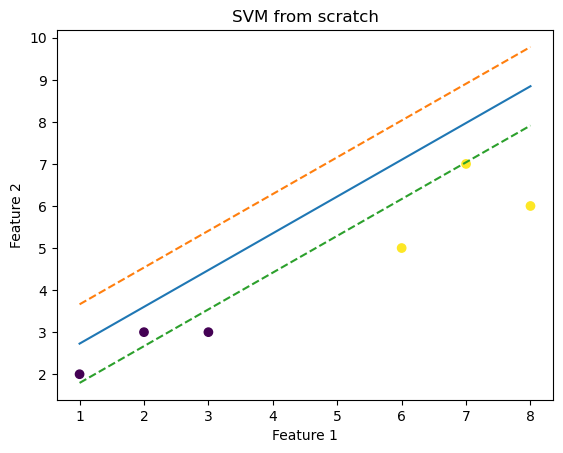

In [3]:
import numpy as np  # bibliothèque pour calculs mathématiques (vecteurs, matrices)
import matplotlib.pyplot as plt     # pour visualisation



# ==============================
# 1. CLASSE SVM
# ==============================
class SVM:
    
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate      # vitesse d'apprentissage (taille des corrections)
        self.lambda_param = lambda_param  #  régularisation (contrôle la complexité du modèle)
        self.n_iters = n_iters      # nombre d'itérations d'apprentissage
        
        self.w = None  # poids du modèle (détermine la frontière)
        self.b = None  # biais (déplace la frontière)

    # ==============================
    # 2. ENTRAINEMENT
    # ==============================
    def fit(self, X, y):
        n_samples, n_features = X.shape  # nombre de données et caractéristiques
        
        # transformation des labels en -1 et +1 (obligatoire en SVM)
        y_ = np.where(y <= 0, -1, 1)

        # initialisation des paramètres
        self.w = np.zeros(n_features)  # frontière au départ = neutre
        self.b = 0

        # ==============================
        # 3. APPRENTISSAGE (GRADIENT DESCENT)
        # ==============================
        for _ in range(self.n_iters):  # répétition pour apprendre progressivement
            
            for idx, x_i in enumerate(X):  # parcourir chaque point
                
                # ==============================
                # CONDITION SVM
                # ==============================
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                
                # ==============================
                # CAS 1 : POINT BIEN CLASSÉ
                # ==============================
                if condition:
                    #  RÉGULARISATION APPLIQUÉE ICI
                    #  on empêche w de devenir trop grand
                    #  donc on évite un modèle trop complexe
                    self.w -= self.lr * (2 * self.lambda_param * self.w)

                # ==============================
                # CAS 2 : POINT MAL CLASSÉ
                # ==============================
                else:
                    # correction du modèle + régularisation
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    # ==============================
    # 4. PRÉDICTION
    # ==============================
    def predict(self, X):
        # calcul du score (distance signée à la frontière)
        linear_output = np.dot(X, self.w) + self.b
        
        # +1 ou -1 selon le côté de la frontière
        return np.sign(linear_output)

# ==============================
# 4. DATASET SIMPLE
# ==============================
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
])  # coordonnées des points

y = np.array([0, 0, 0, 1, 1, 1])  # classes (0 et 1)


# ==============================
# 5. ENTRAINEMENT
# ==============================
model = SVM()     # créer le modèle
model.fit(X, y)   # entraîner le modèle


# ==============================
# 6. TEST
# ==============================
X_test = np.array([[5, 5]])          # nouveau point
prediction = model.predict(X_test)   # prédiction

print("Prédiction SVM :", prediction)


# ==============================
# 7. VISUALISATION
# ==============================
def plot_svm(model):
    
    def hyperplane(x, w, b, offset):
        # équation de la droite : w.x + b = offset
        return (-w[0] * x - b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)

    # afficher les points
    plt.scatter(X[:,0], X[:,1], c=y)

    # bornes
    x0_1 = np.min(X[:,0])
    x0_2 = np.max(X[:,0])

    # hyperplan principal (séparation)
    x1_1 = hyperplane(x0_1, model.w, model.b, 0)
    x1_2 = hyperplane(x0_2, model.w, model.b, 0)
    ax.plot([x0_1, x0_2], [x1_1, x1_2])

    # marges (lignes parallèles)
    x1_1 = hyperplane(x0_1, model.w, model.b, -1)
    x1_2 = hyperplane(x0_2, model.w, model.b, -1)
    ax.plot([x0_1, x0_2], [x1_1, x1_2], linestyle="--")

    x1_1 = hyperplane(x0_1, model.w, model.b, 1)
    x1_2 = hyperplane(x0_2, model.w, model.b, 1)
    ax.plot([x0_1, x0_2], [x1_1, x1_2], linestyle="--")

    plt.title("SVM from scratch")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# appeler la fonction de visualisation
plot_svm(model)